#### Definition
1. um, fs, keV
2. normal is pointing inwards the reflection surface
3. The coordinate convention of this simulation and its relation to XPP coordinate is 
    (axis 0, axis 1, axis 2) = (vertical, horizontal, propagation) = (xpp y, xpp x, xpp z)
    i.e., The name in this code is x,y,z, using one convension. In the text, use the XPP convention 

np.fft(field) = spectrum

np.ifft(spectrum) = field

# Step 1: Ray Tracing Calculation

In [1]:
import time
import sys
sys.path.append("../../../../XRaySimulation")

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps

# Level 1 dependence
from XRaySimulation import Pulse, DeviceSimu, util

# Level 2 dependece
import rayTracingCalculation
import physicalModelVisualization
#import eFieldProcessing
import parser
import Controller

plt.rcParams.update({'font.size': 14})

In [2]:
# Create the experiment setup
exp = Controller.XppController_TG()

Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, rotating around y axis.
Create a SA07A motor, rotating around z axis.
Create a XA10A motor, moving along x axis.
Create a XA10A motor, moving along y axis.
Create a RA10A motor, ro

# Align the mono

### Mono before alignment

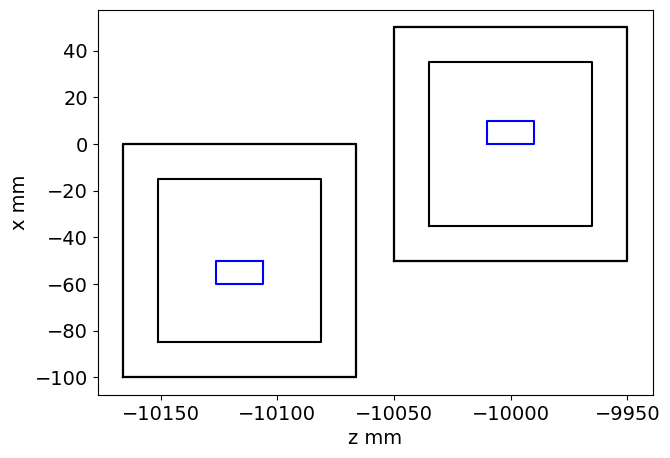

In [3]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.mono_t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.mono_t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')


#ax.set_xlim([6000, 8000])
#ax.set_ylim([-10, 10])

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()


### Mono after alignment

In [4]:
monot1_rocking, monot2_rocking = exp.align_xpp_mono()

Motor moved to -17.88927 deg
Motor moved to -17.88927 deg
Motor moved to -17.89039 deg
Motor moved to -17.89026 deg


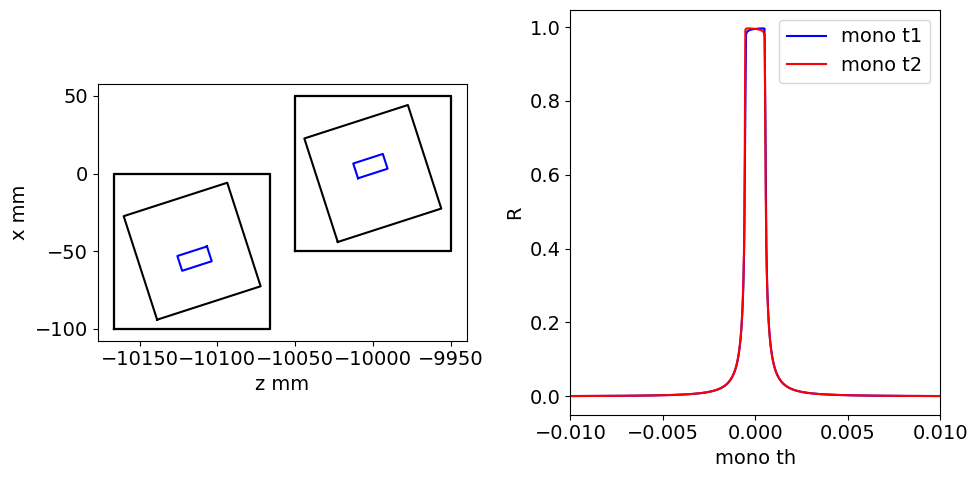

In [5]:
fig, ax = plt.subplots(ncols=2, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.mono_t1.all_motors:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t1.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.mono_t2.all_motors:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
                
for item in exp.mono_t2.all_optics:
    ax[0].plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

ax[0].set_aspect('equal')
ax[0].set_xlabel("z mm")
ax[0].set_ylabel("x mm")

ax[1].plot(np.rad2deg(exp.mono_t1_rocking[0]), monot1_rocking[1], c='b', label='mono t1')
ax[1].plot(np.rad2deg(exp.mono_t2_rocking[0]), monot2_rocking[1], c='r', label='mono t2')
ax[1].set_xlim([-0.01, 0.01])
ax[1].set_xlabel("mono th")
ax[1].set_ylabel("R")
ax[1].legend()

plt.tight_layout()
plt.show()


# Align the miniSD

### miniSD before alignment

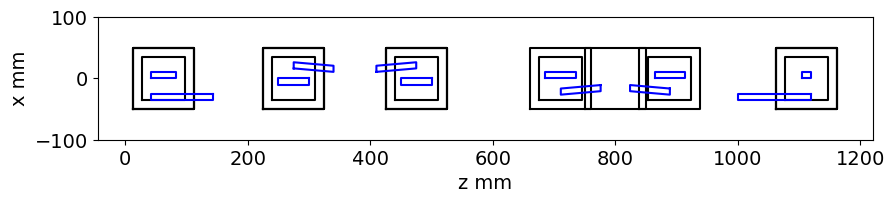

In [6]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t3.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t3.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t45.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t45.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t6.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t6.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

#ax.set_xlim([6000, 8000])
ax.set_ylim([-100, 100])

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()

### miniSD after alignment

In [7]:
exp.align_miniSD()

Motor moved to 19.23525 deg
Motor moved to -19.23525 deg
Motor moved to 19.23525 deg
Motor moved to -19.23525 deg
Motor moved to 19.23525 deg
Motor moved to -19.23525 deg
Motor moved to 19.23514 deg
Motor moved to -19.23790 deg
Motor moved to -19.23729 deg
Motor moved to 19.23581 deg
Motor moved to -19.23616 deg
Motor moved to 19.23544 deg


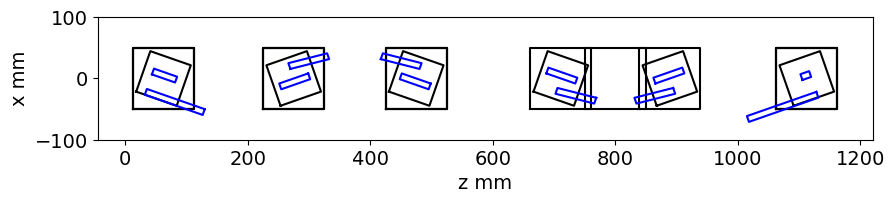

In [8]:
fig, ax = plt.subplots(ncols=1, nrows=1)
fig.set_figheight(5)
fig.set_figwidth(10)

for item in exp.t1.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t1.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t2.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t2.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t3.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t3.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t45.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t45.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

for item in exp.t6.all_motors:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='black')
for item in exp.t6.all_optics:
    ax.plot(item.boundary[:, 2] / 1000, item.boundary[:, 1] / 1000, c='blue')

#ax.set_xlim([6000, 8000])
ax.set_ylim([-100, 100])

ax.set_aspect('equal')
ax.set_xlabel("z mm")
ax.set_ylabel("x mm")

plt.show()

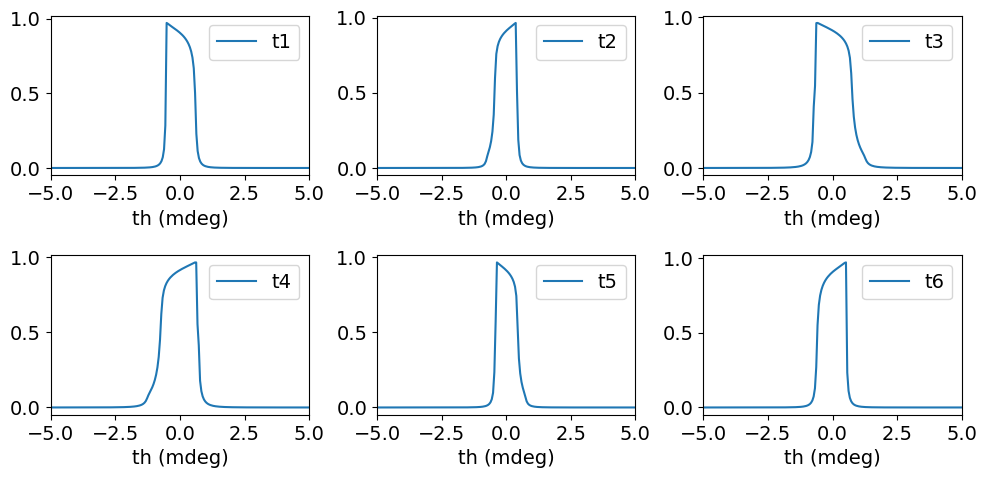

In [10]:
fig, ax = plt.subplots(ncols=3, nrows=2)
fig.set_figheight(5)
fig.set_figwidth(10)

record_to_plot = [exp.t1_rocking, exp.t2_rocking, exp.t3_rocking, exp.t4_rocking, exp.t5_rocking, exp.t6_rocking]
for idx in range(2):
    for idx2 in range(3):
        record = record_to_plot[idx2 + idx * 3]
        ax[idx, idx2].plot(np.rad2deg(record[0]) * 1000, record[1], label='t{}'.format(idx2 + 3 * idx + 1))
        ax[idx, idx2].set_xlabel('th (mdeg)')
        ax[idx, idx2].legend()
        ax[idx, idx2].set_xlim([-5, 5])


plt.tight_layout()
plt.show()

# Align the total reflection mirrors to the ideal angle